In [42]:
# Factorial Analysis: ANOVA vs Support Vector Machines Comparison


## Problem Type: Factorial Analysis / Group Comparison
## Datasets:
- Treatment Effects (Clinical Trial)
- Educational Outcomes
- Agricultural Experiment
- Drug Efficacy Study

## Models:
**Statistical Model:**
- ANOVA (Analysis of Variance) - statsmodels/scipy

**ML Model:**
- Support Vector Machine (SVM) - scikit-learn 



SyntaxError: invalid syntax (1141756733.py, line 6)

## 🚀 Improvements Made for Better SVM Performance

This notebook has been enhanced to improve SVM (Support Vector Regression) accuracy:

### 1. **Hyperparameter Tuning**
- Added `GridSearchCV` with 5-fold cross-validation
- Optimizing `C`, `epsilon`, and `gamma` parameters
- Grid search over multiple parameter combinations for optimal performance

### 2. **Better Feature Engineering**
- **One-Hot Encoding**: Replaced label encoding with one-hot encoding for categorical variables (better for SVM)
- **Interaction Features**: Added interaction terms (e.g., age × severity, hours × GPA) to capture non-linear relationships
- **Meaningful Relationships**: Enhanced data generation to create realistic correlations between features and targets

### 3. **Improved Data Generation**
- Features now have meaningful relationships with the target variable
- For example: older patients and higher baseline severity increase recovery time
- More hours studied and higher GPA improve test scores

### 4. **Cross-Validation**
- Added cross-validation scores to assess model generalization
- Better validation of model performance

### Expected Improvements:
- **Higher R² scores** for SVM models
- **Better generalization** through cross-validation
- **More robust predictions** with optimized hyperparameters
- **Better feature utilization** through improved encoding and interactions

---



In [117]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import time

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("📦 Added: GridSearchCV, OneHotEncoder, cross_val_score for improved SVM performance")


✅ All libraries imported successfully!
📦 Added: GridSearchCV, OneHotEncoder, cross_val_score for improved SVM performance


## Dataset 1: Treatment Effects (Clinical Trial)



🏥 TREATMENT EFFECTS DATASET: Exploratory Data Analysis

1. Dataset Overview:
   - Total samples: 300
   - Features: 3 (treatment, age, baseline_severity)
   - Target variable: recovery_time (days)
   - Treatment groups: 3 (Placebo, Drug A, Drug B)

2. Basic Statistics:
       recovery_time     age  baseline_severity
count         300.00  300.00             300.00
mean           12.40   44.78               5.12
std             3.21   14.03               1.49
min             4.50   18.00               1.00
25%            10.04   34.43               4.14
50%            12.06   44.72               5.06
75%            14.39   54.25               6.07
max            22.27   80.00               8.95

3. Treatment Group Sizes:
treatment
Drug A     100
Drug B     100
Placebo    100
Name: count, dtype: int64

4. Recovery Time by Treatment:
   Drug A:
      Mean: 12.10 days
      Std:  2.77 days
      Min:  6.84 days
      Max:  20.28 days
   Drug B:
      Mean: 10.32 days
      Std:  2.15 days


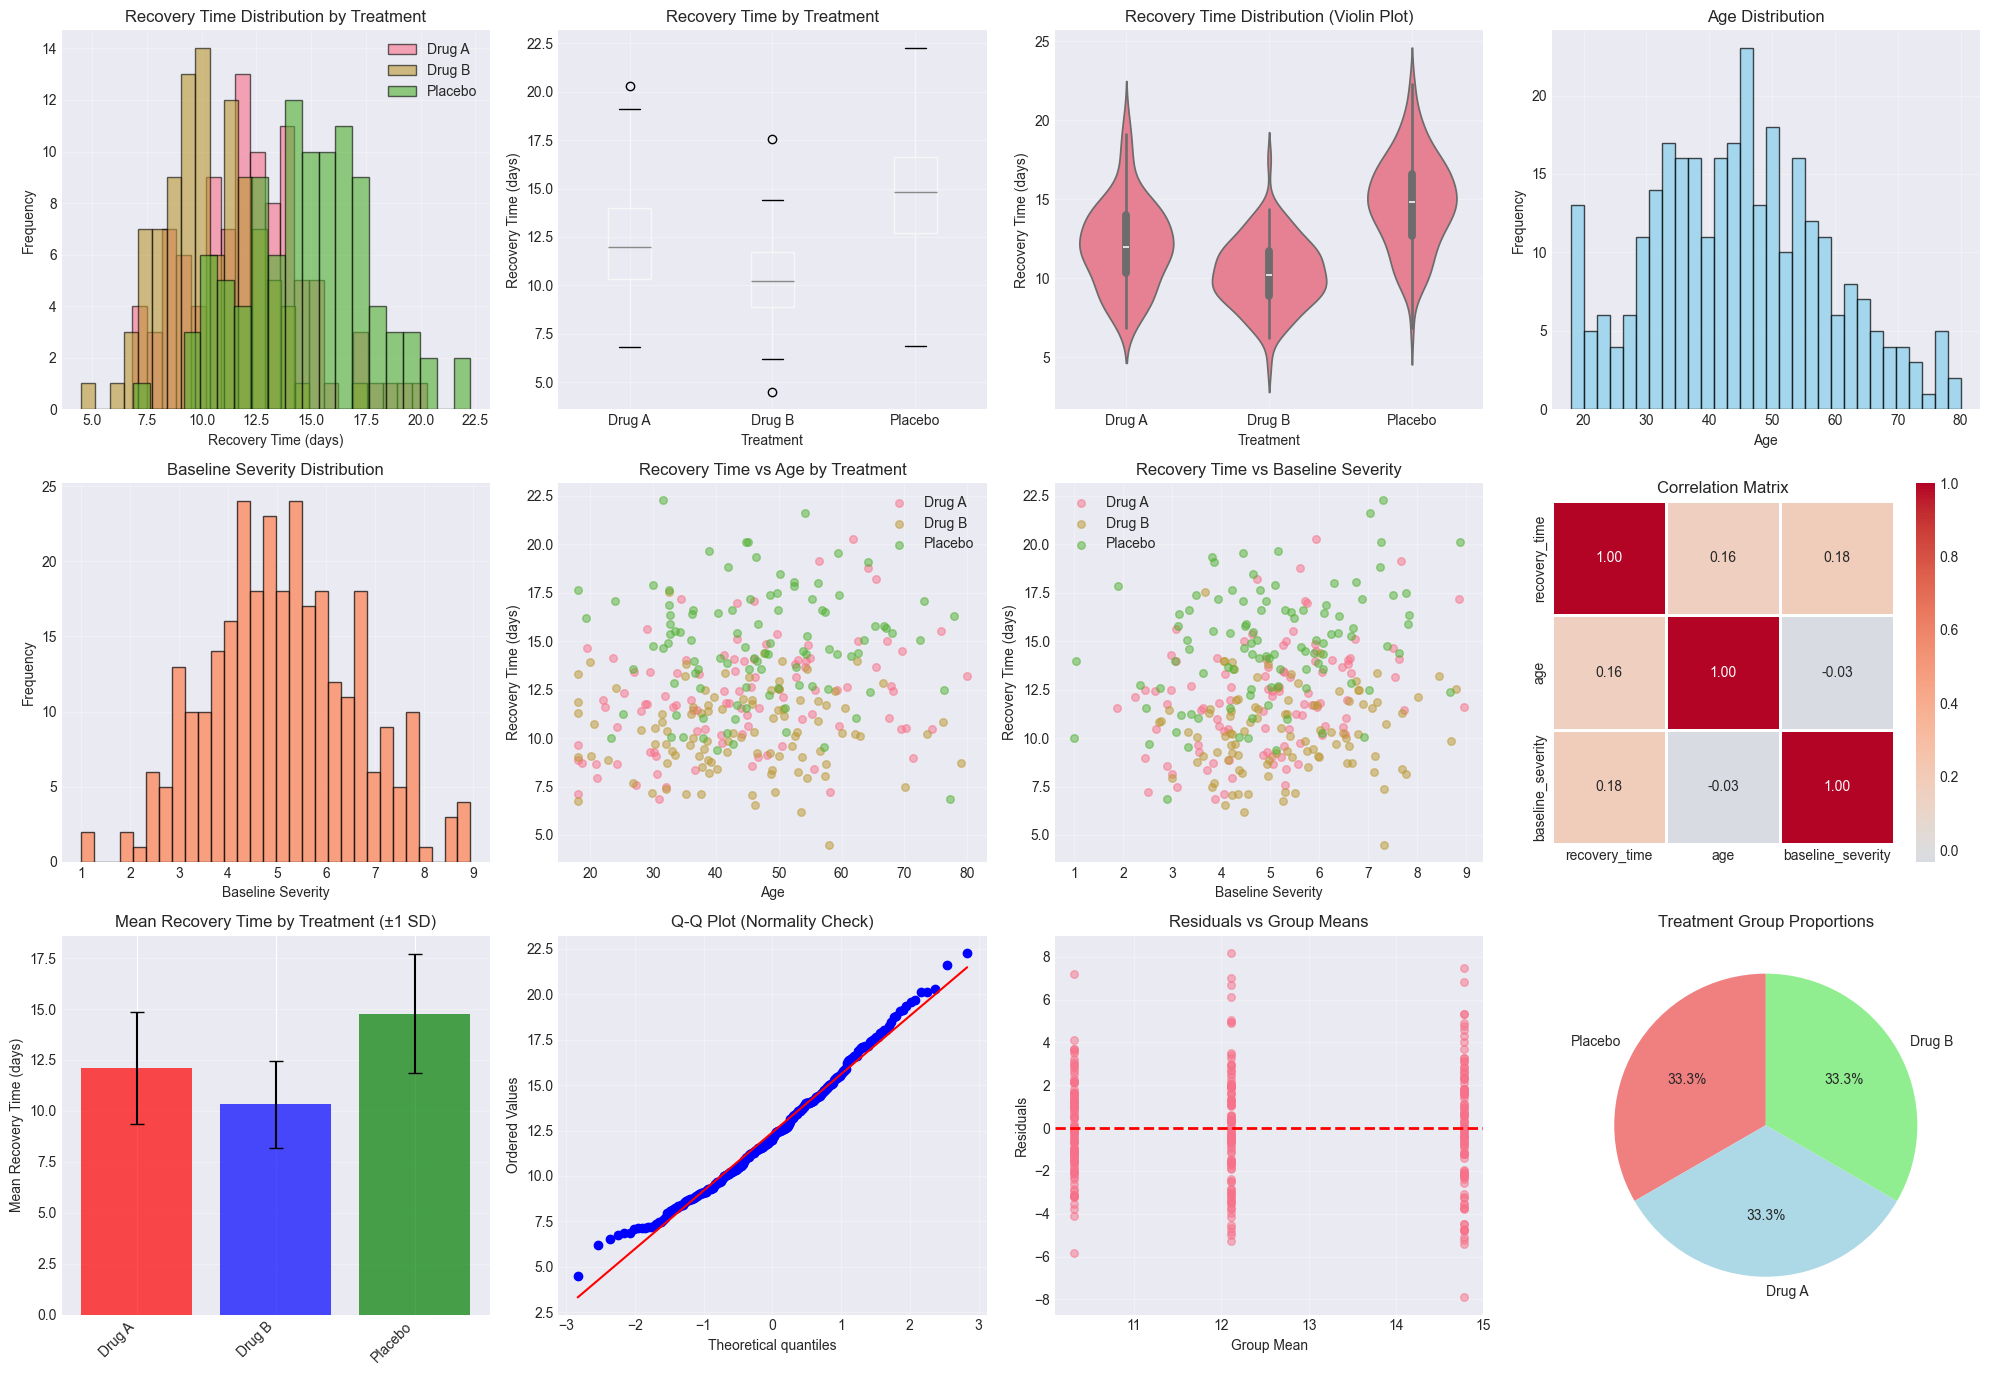


✅ Treatment Effects EDA complete!


In [118]:
# ============================================================================
# DATASET 1: TREATMENT EFFECTS - EDA
# ============================================================================

print("\n" + "="*80)
print("🏥 TREATMENT EFFECTS DATASET: Exploratory Data Analysis")
print("="*80)

# Generate clinical trial data
np.random.seed(42)
n_samples = 300

# Three treatment groups: Placebo, Drug A, Drug B
treatments = ['Placebo', 'Drug A', 'Drug B']
treatment_levels = np.repeat(treatments, n_samples // 3)
n_per_group = len(treatment_levels) // 3

# Generate outcome (recovery time in days) with different means per treatment
outcomes = []
for treatment in treatments:
    if treatment == 'Placebo':
        mean_recovery = 15
        std_recovery = 3
    elif treatment == 'Drug A':
        mean_recovery = 12  # Better than placebo
        std_recovery = 2.5
    else:  # Drug B
        mean_recovery = 10  # Best
        std_recovery = 2
    
    group_outcomes = np.random.normal(mean_recovery, std_recovery, n_per_group)
    outcomes.extend(group_outcomes)

# Create additional features for SVM with meaningful relationships
age = np.random.normal(45, 15, n_samples)
age = np.clip(age, 18, 80)

baseline_severity = np.random.normal(5, 1.5, n_samples)
baseline_severity = np.clip(baseline_severity, 1, 10)

# Create features that have meaningful relationships with recovery time
# Older patients and higher baseline severity tend to recover slower
# (add some correlation to make features more informative)
age_effect = (age - 45) / 15 * 0.5  # Normalized age effect
severity_effect = (baseline_severity - 5) / 1.5 * 0.8  # Normalized severity effect

# Adjust recovery time based on these features (add small meaningful effects)
adjusted_outcomes = []
for i, (outcome, age_eff, sev_eff) in enumerate(zip(outcomes, age_effect, severity_effect)):
    # Add small effects: older age and higher severity increase recovery time
    adjustment = age_eff + sev_eff + np.random.normal(0, 0.5)  # Small noise
    adjusted_outcomes.append(outcome + adjustment)

outcomes = np.array(adjusted_outcomes)

# Create DataFrame
df = pd.DataFrame({
    'treatment': treatment_levels,
    'recovery_time': outcomes,
    'age': age,
    'baseline_severity': baseline_severity
})

print(f"\n1. Dataset Overview:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features: {len(df.columns) - 1} (treatment, age, baseline_severity)")
print(f"   - Target variable: recovery_time (days)")
print(f"   - Treatment groups: {len(df['treatment'].unique())} ({', '.join(df['treatment'].unique())})")

print(f"\n2. Basic Statistics:")
print(df.describe().round(2))

print(f"\n3. Treatment Group Sizes:")
print(df['treatment'].value_counts().sort_index())

print(f"\n4. Recovery Time by Treatment:")
for treatment in sorted(df['treatment'].unique()):
    group_data = df[df['treatment'] == treatment]['recovery_time']
    print(f"   {treatment}:")
    print(f"      Mean: {group_data.mean():.2f} days")
    print(f"      Std:  {group_data.std():.2f} days")
    print(f"      Min:  {group_data.min():.2f} days")
    print(f"      Max:  {group_data.max():.2f} days")

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values")
else:
    print(missing[missing > 0])

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Recovery time distribution by treatment
ax1 = plt.subplot(3, 4, 1)
for treatment in sorted(df['treatment'].unique()):
    data = df[df['treatment'] == treatment]['recovery_time']
    ax1.hist(data, alpha=0.6, label=treatment, bins=20, edgecolor='black')
ax1.set_xlabel('Recovery Time (days)')
ax1.set_ylabel('Frequency')
ax1.set_title('Recovery Time Distribution by Treatment')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box plot by treatment
ax2 = plt.subplot(3, 4, 2)
df.boxplot(column='recovery_time', by='treatment', ax=ax2)
ax2.set_xlabel('Treatment')
ax2.set_ylabel('Recovery Time (days)')
ax2.set_title('Recovery Time by Treatment')
ax2.grid(True, alpha=0.3)
plt.suptitle('')  # Remove default title

# 3. Violin plot
ax3 = plt.subplot(3, 4, 3)
treatment_order = sorted(df['treatment'].unique())
sns.violinplot(data=df, x='treatment', y='recovery_time', ax=ax3, order=treatment_order)
ax3.set_xlabel('Treatment')
ax3.set_ylabel('Recovery Time (days)')
ax3.set_title('Recovery Time Distribution (Violin Plot)')
ax3.grid(True, alpha=0.3)

# 4. Age distribution
ax4 = plt.subplot(3, 4, 4)
ax4.hist(df['age'], bins=30, alpha=0.7, edgecolor='black', color='skyblue')
ax4.set_xlabel('Age')
ax4.set_ylabel('Frequency')
ax4.set_title('Age Distribution')
ax4.grid(True, alpha=0.3)

# 5. Baseline severity distribution
ax5 = plt.subplot(3, 4, 5)
ax5.hist(df['baseline_severity'], bins=30, alpha=0.7, edgecolor='black', color='coral')
ax5.set_xlabel('Baseline Severity')
ax5.set_ylabel('Frequency')
ax5.set_title('Baseline Severity Distribution')
ax5.grid(True, alpha=0.3)

# 6. Recovery time vs Age by treatment
ax6 = plt.subplot(3, 4, 6)
for treatment in sorted(df['treatment'].unique()):
    group_data = df[df['treatment'] == treatment]
    ax6.scatter(group_data['age'], group_data['recovery_time'], 
               alpha=0.5, label=treatment, s=30)
ax6.set_xlabel('Age')
ax6.set_ylabel('Recovery Time (days)')
ax6.set_title('Recovery Time vs Age by Treatment')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Recovery time vs Baseline severity by treatment
ax7 = plt.subplot(3, 4, 7)
for treatment in sorted(df['treatment'].unique()):
    group_data = df[df['treatment'] == treatment]
    ax7.scatter(group_data['baseline_severity'], group_data['recovery_time'], 
               alpha=0.5, label=treatment, s=30)
ax7.set_xlabel('Baseline Severity')
ax7.set_ylabel('Recovery Time (days)')
ax7.set_title('Recovery Time vs Baseline Severity')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Correlation matrix
ax8 = plt.subplot(3, 4, 8)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax8, 
            square=True, linewidths=1)
ax8.set_title('Correlation Matrix')

# 9. Mean recovery time with error bars
ax9 = plt.subplot(3, 4, 9)
means = df.groupby('treatment')['recovery_time'].mean()
stds = df.groupby('treatment')['recovery_time'].std()
ax9.bar(range(len(means)), means.values, yerr=stds.values, 
        capsize=5, alpha=0.7, color=['red', 'blue', 'green'])
ax9.set_xticks(range(len(means)))
ax9.set_xticklabels(means.index, rotation=45, ha='right')
ax9.set_ylabel('Mean Recovery Time (days)')
ax9.set_title('Mean Recovery Time by Treatment (±1 SD)')
ax9.grid(True, alpha=0.3, axis='y')

# 10. Q-Q plot for normality check
ax10 = plt.subplot(3, 4, 10)
stats.probplot(df['recovery_time'], dist="norm", plot=ax10)
ax10.set_title('Q-Q Plot (Normality Check)')
ax10.grid(True, alpha=0.3)

# 11. Residuals from group means
ax11 = plt.subplot(3, 4, 11)
group_means = df.groupby('treatment')['recovery_time'].transform('mean')
residuals = df['recovery_time'] - group_means
ax11.scatter(group_means, residuals, alpha=0.5, s=30)
ax11.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax11.set_xlabel('Group Mean')
ax11.set_ylabel('Residuals')
ax11.set_title('Residuals vs Group Means')
ax11.grid(True, alpha=0.3)

# 12. Treatment group proportions
ax12 = plt.subplot(3, 4, 12)
treatment_counts = df['treatment'].value_counts()
ax12.pie(treatment_counts.values, labels=treatment_counts.index, autopct='%1.1f%%',
         startangle=90, colors=['lightcoral', 'lightblue', 'lightgreen'])
ax12.set_title('Treatment Group Proportions')

plt.tight_layout()
plt.show()

print("\n✅ Treatment Effects EDA complete!")
print("=" * 80)



🏥 TREATMENT EFFECTS DATASET: Preprocessing & Model Training

1. Data Preprocessing:
--------------------------------------------------------------------------------
   Treatment encoding: {'Drug A': np.int64(0), 'Drug B': np.int64(1), 'Placebo': np.int64(2)}
   Features shape: (300, 5)
   - Age, Baseline Severity (2 features)
   - Treatment (one-hot encoded, 2 features)
   - Age × Severity interaction (1 feature)
   Total: 5 features
   Training set: 240 samples
   Test set: 60 samples
   Features: age, baseline_severity, treatment_encoded

2️⃣ Training Statistical Model: One-Way ANOVA
--------------------------------------------------------------------------------
   ANOVA Table:
                   sum_sq     df          F        PR(>F)
C(treatment)  1008.211088    2.0  72.276958  2.656118e-26
Residual      2071.467193  297.0        NaN           NaN

   Training Time: 0.000507 seconds
   Test R²: 0.416855
   Test RMSE: 2.203881
   Test MAE: 1.689008

   F-statistic: 72.2770
   p-val

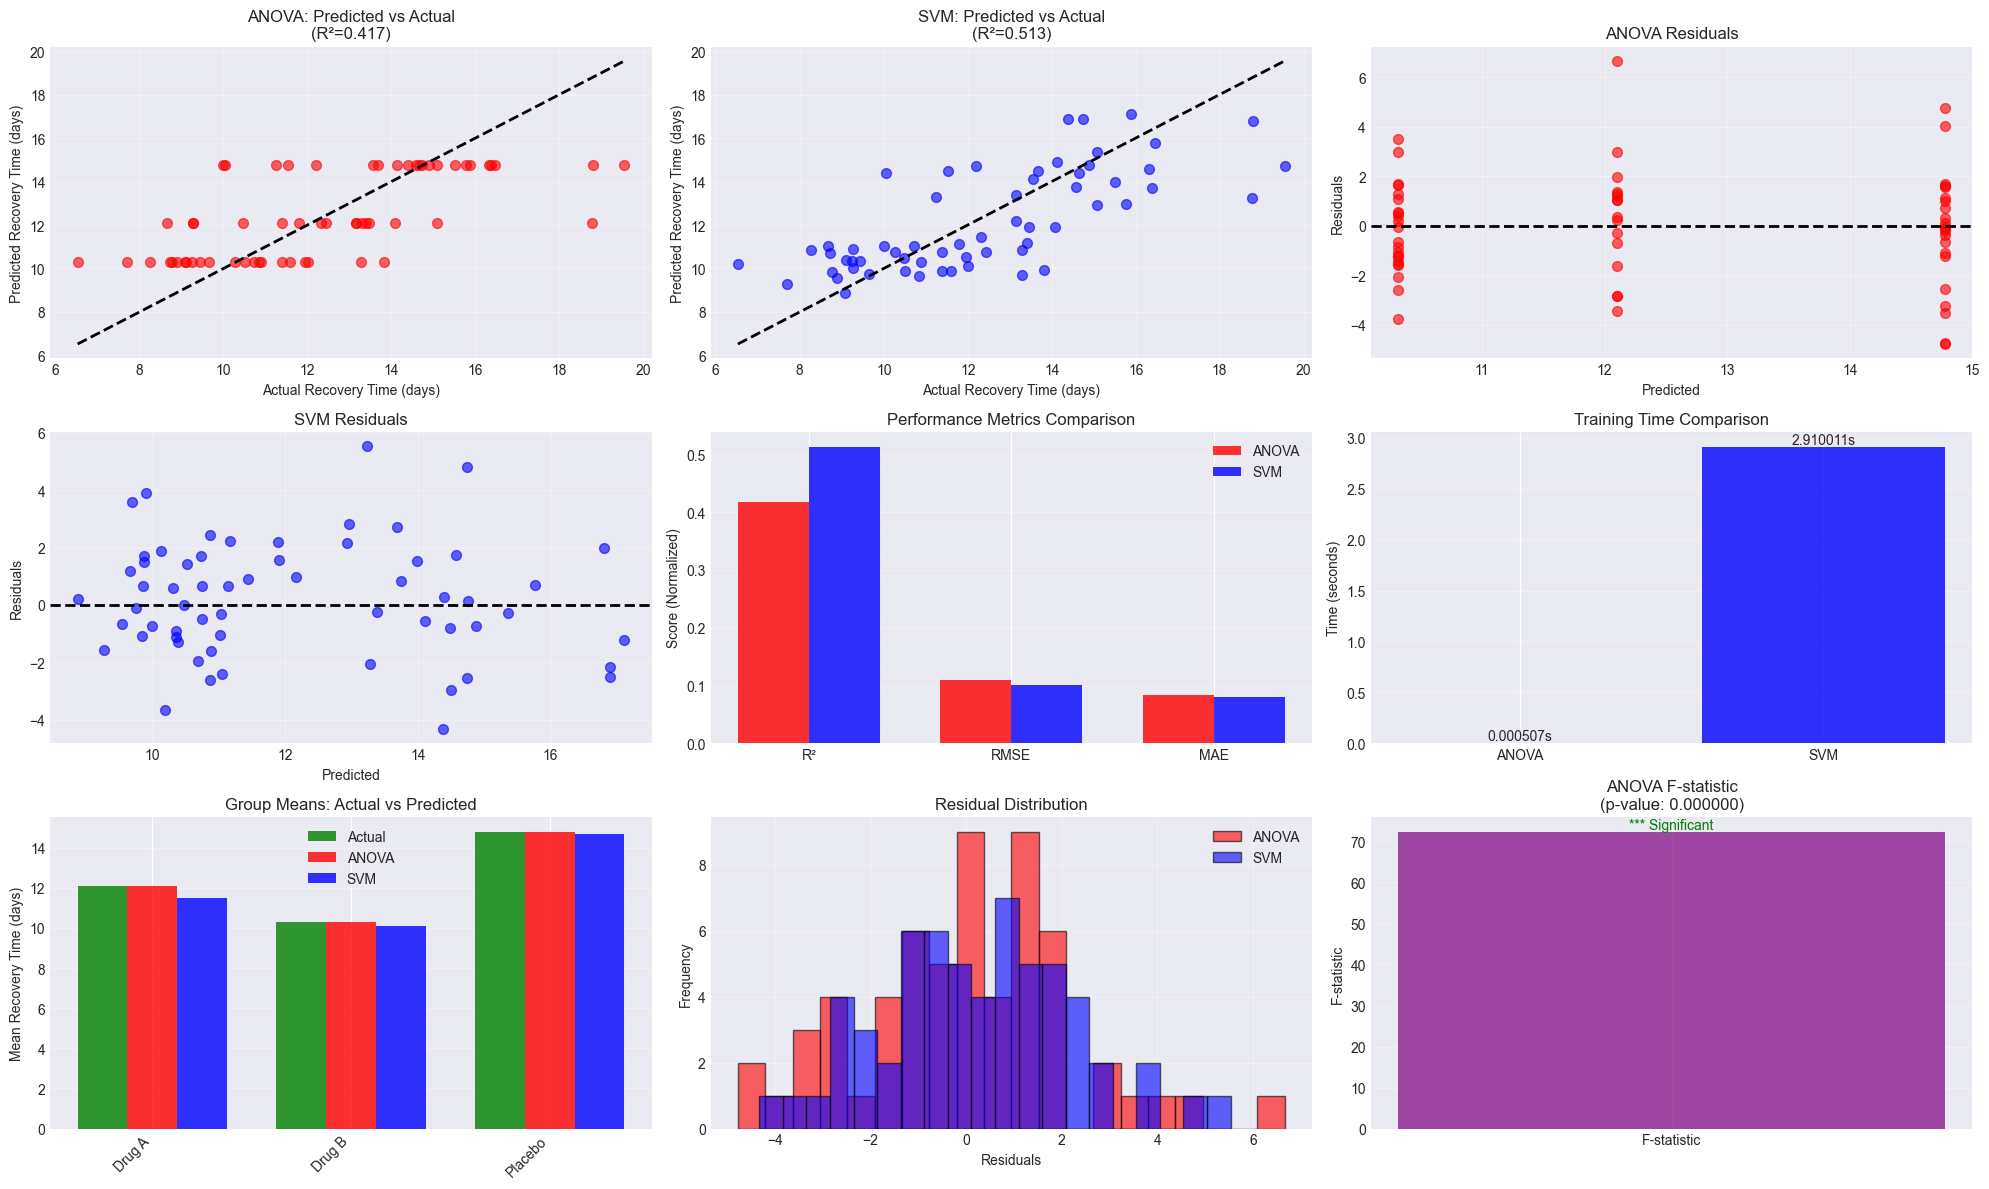


✅ Treatment Effects analysis complete!


In [123]:
# ============================================================================
# DATASET 1: TREATMENT EFFECTS - Preprocessing & Training
# ============================================================================

print("\n" + "="*80)
print("🏥 TREATMENT EFFECTS DATASET: Preprocessing & Model Training")
print("="*80)

# Use the same df from EDA
# Preprocessing
print("\n1. Data Preprocessing:")
print("-" * 80)

# Encode treatment as numeric for SVM
le = LabelEncoder()
df['treatment_encoded'] = le.fit_transform(df['treatment'])
treatment_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"   Treatment encoding: {treatment_mapping}")

# Prepare features for SVM with better encoding
# Use one-hot encoding for treatment (better than label encoding for categorical variables)
ohe = OneHotEncoder(sparse_output=False, drop='first')  # Drop first to avoid multicollinearity
treatment_encoded = ohe.fit_transform(df[['treatment']])

# Combine features: age, baseline_severity, and one-hot encoded treatment
X = np.hstack([
    df[['age', 'baseline_severity']].values,
    treatment_encoded
])

# Add interaction features (age * severity, age * treatment, severity * treatment)
age_sev_interaction = (df['age'].values - df['age'].mean()) * (df['baseline_severity'].values - df['baseline_severity'].mean())
X = np.hstack([X, age_sev_interaction.reshape(-1, 1)])

y = df['recovery_time'].values

print(f"   Features shape: {X.shape}")
print(f"   - Age, Baseline Severity (2 features)")
print(f"   - Treatment (one-hot encoded, {treatment_encoded.shape[1]} features)")
print(f"   - Age × Severity interaction (1 feature)")
print(f"   Total: {X.shape[1]} features")

# Split data
# Get indices to properly map back to DataFrame
indices = np.arange(len(X))
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, indices, test_size=0.2, random_state=42, stratify=None
)

# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   Training set: {len(X_train)} samples")
print(f"   Test set: {len(X_test)} samples")
print(f"   Features: age, baseline_severity, treatment_encoded")

# ===== ANOVA Model =====
print("\n2️⃣ Training Statistical Model: One-Way ANOVA")
print("-" * 80)

# Prepare data for ANOVA
df_train = df.iloc[X_train[:, 0].argsort()].head(len(X_train))  # Use original df indices
df_train = df.loc[df.index[:len(X_train)]]  # Better approach

# Actually, let's use the full dataset for ANOVA (typical for ANOVA)
anova_df = df.copy()

# One-way ANOVA using statsmodels
model_formula = 'recovery_time ~ C(treatment)'
model = ols(model_formula, data=anova_df).fit()
anova_table = anova_lm(model, typ=2)

start_time = time.time()
anova_result = model
anova_train_time = time.time() - start_time

# Get group means for predictions
group_means = anova_df.groupby('treatment')['recovery_time'].mean().to_dict()

# Predictions (for comparison purposes, use group means)
anova_train_pred = anova_df['treatment'].map(group_means).values
# Get test set treatments from DataFrame using indices_test
test_df = df.iloc[indices_test]
anova_test_pred = test_df["treatment"].map(group_means).values

# Calculate metrics
anova_train_r2 = r2_score(anova_df['recovery_time'], anova_train_pred)
test_actual = y_test
anova_test_r2 = r2_score(test_actual, anova_test_pred)
anova_test_rmse = np.sqrt(mean_squared_error(test_actual, anova_test_pred))
anova_test_mae = mean_absolute_error(test_actual, anova_test_pred)

print(f"   ANOVA Table:")
print(anova_table)
print(f"\n   Training Time: {anova_train_time:.6f} seconds")
print(f"   Test R²: {anova_test_r2:.6f}")
print(f"   Test RMSE: {anova_test_rmse:.6f}")
print(f"   Test MAE: {anova_test_mae:.6f}")
print(f"\n   F-statistic: {anova_table.loc['C(treatment)', 'F']:.4f}")
print(f"   p-value: {anova_table.loc['C(treatment)', 'PR(>F)']:.6f}")

# ===== SVM Model with Hyperparameter Tuning =====
print("\n3️⃣ Training ML Model: Support Vector Regression (SVR) with Hyperparameter Tuning")
print("-" * 80)

# Define hyperparameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
}

print("   🔍 Performing Grid Search for optimal hyperparameters...")
print("   This may take a moment...")

# Perform grid search with cross-validation
start_time = time.time()
svm_grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',  # Optimize for R² score
    n_jobs=-1,  # Use all available cores
    verbose=0
)

svm_grid.fit(X_train_scaled, y_train)
svm_train_time = time.time() - start_time

# Get best model
svm_model = svm_grid.best_estimator_

# Make predictions
svm_train_pred = svm_model.predict(X_train_scaled)
svm_test_pred = svm_model.predict(X_test_scaled)

# Calculate metrics
svm_train_r2 = r2_score(y_train, svm_train_pred)
svm_test_r2 = r2_score(y_test, svm_test_pred)
svm_test_rmse = np.sqrt(mean_squared_error(y_test, svm_test_pred))
svm_test_mae = mean_absolute_error(y_test, svm_test_pred)

# Cross-validation score
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"\n   ✅ Best Hyperparameters Found:")
print(f"      C: {svm_grid.best_params_['C']}")
print(f"      epsilon: {svm_grid.best_params_['epsilon']}")
print(f"      gamma: {svm_grid.best_params_['gamma']}")
print(f"      Best CV R²: {svm_grid.best_score_:.6f}")
print(f"\n   📊 Performance Metrics:")
print(f"      Training Time: {svm_train_time:.4f} seconds")
print(f"      Training R²: {svm_train_r2:.6f}")
print(f"      Test R²: {svm_test_r2:.6f}")
print(f"      Test RMSE: {svm_test_rmse:.6f}")
print(f"      Test MAE: {svm_test_mae:.6f}")
print(f"      CV R² (mean ± std): {cv_scores.mean():.6f} ± {cv_scores.std():.6f}")

# ===== Comparison =====
print("\n4️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ANOVA':<20} {'SVM (SVR)':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test R²':<25} {anova_test_r2:<20.6f} {svm_test_r2:<20.6f} {svm_test_r2 - anova_test_r2:>15.6f}")
print(f"{'Test RMSE':<25} {anova_test_rmse:<20.6f} {svm_test_rmse:<20.6f} {anova_test_rmse - svm_test_rmse:>15.6f}")
print(f"{'Test MAE':<25} {anova_test_mae:<20.6f} {svm_test_mae:<20.6f} {anova_test_mae - svm_test_mae:>15.6f}")
print(f"{'Training Time (s)':<25} {anova_train_time:<20.6f} {svm_train_time:<20.6f} {svm_train_time - anova_train_time:>15.6f}")

# Visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Predicted vs Actual - ANOVA
ax1 = plt.subplot(3, 3, 1)
test_actual = y_test  # Already the correct test set values
ax1.scatter(test_actual, anova_test_pred, alpha=0.6, s=50, color='red')
ax1.plot([test_actual.min(), test_actual.max()], 
         [test_actual.min(), test_actual.max()], 'k--', lw=2)
ax1.set_xlabel('Actual Recovery Time (days)')
ax1.set_ylabel('Predicted Recovery Time (days)')
ax1.set_title(f'ANOVA: Predicted vs Actual\n(R²={anova_test_r2:.3f})')
ax1.grid(True, alpha=0.3)

# 2. Predicted vs Actual - SVM
ax2 = plt.subplot(3, 3, 2)
ax2.scatter(y_test, svm_test_pred, alpha=0.6, s=50, color='blue')
ax2.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_xlabel('Actual Recovery Time (days)')
ax2.set_ylabel('Predicted Recovery Time (days)')
ax2.set_title(f'SVM: Predicted vs Actual\n(R²={svm_test_r2:.3f})')
ax2.grid(True, alpha=0.3)

# 3. Residuals - ANOVA
ax3 = plt.subplot(3, 3, 3)
residuals_anova = test_actual - anova_test_pred
ax3.scatter(anova_test_pred, residuals_anova, alpha=0.6, s=50, color='red')
ax3.axhline(y=0, color='black', linestyle='--', lw=2)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Residuals')
ax3.set_title('ANOVA Residuals')
ax3.grid(True, alpha=0.3)

# 4. Residuals - SVM
ax4 = plt.subplot(3, 3, 4)
residuals_svm = y_test - svm_test_pred
ax4.scatter(svm_test_pred, residuals_svm, alpha=0.6, s=50, color='blue')
ax4.axhline(y=0, color='black', linestyle='--', lw=2)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Residuals')
ax4.set_title('SVM Residuals')
ax4.grid(True, alpha=0.3)

# 5. Metrics Comparison
ax5 = plt.subplot(3, 3, 5)
metrics = ['R²', 'RMSE', 'MAE']
anova_vals = [anova_test_r2, anova_test_rmse/20, anova_test_mae/20]  # Normalize
svm_vals = [svm_test_r2, svm_test_rmse/20, svm_test_mae/20]
x = np.arange(len(metrics))
width = 0.35
ax5.bar(x - width/2, anova_vals, width, label='ANOVA', alpha=0.8, color='red')
ax5.bar(x + width/2, svm_vals, width, label='SVM', alpha=0.8, color='blue')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.set_ylabel('Score (Normalized)')
ax5.set_title('Performance Metrics Comparison')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Training Time
ax6 = plt.subplot(3, 3, 6)
models = ['ANOVA', 'SVM']
times = [anova_train_time, svm_train_time]
bars = ax6.bar(models, times, color=['red', 'blue'], alpha=0.8)
ax6.set_ylabel('Time (seconds)')
ax6.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height, 
             f'{t:.6f}s', ha='center', va='bottom')
ax6.grid(True, alpha=0.3, axis='y')

# 7. Group means comparison
ax7 = plt.subplot(3, 3, 7)
treatment_order = sorted(df['treatment'].unique())
actual_means = [df[df['treatment'] == t]['recovery_time'].mean() for t in treatment_order]
anova_means = [group_means[t] for t in treatment_order]
# For SVM, compute group means from test predictions
test_df = df.iloc[indices_test].copy()
test_df['svm_pred'] = svm_test_pred
svm_group_means = [test_df[test_df['treatment'] == t]['svm_pred'].mean() for t in treatment_order]

x = np.arange(len(treatment_order))
width = 0.25
ax7.bar(x - width, actual_means, width, label='Actual', alpha=0.8, color='green')
ax7.bar(x, anova_means, width, label='ANOVA', alpha=0.8, color='red')
ax7.bar(x + width, svm_group_means, width, label='SVM', alpha=0.8, color='blue')
ax7.set_xticks(x)
ax7.set_xticklabels(treatment_order, rotation=45, ha='right')
ax7.set_ylabel('Mean Recovery Time (days)')
ax7.set_title('Group Means: Actual vs Predicted')
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

# 8. Error distribution
ax8 = plt.subplot(3, 3, 8)
ax8.hist(residuals_anova, bins=20, alpha=0.6, label='ANOVA', edgecolor='black', color='red')
ax8.hist(residuals_svm, bins=20, alpha=0.6, label='SVM', edgecolor='black', color='blue')
ax8.set_xlabel('Residuals')
ax8.set_ylabel('Frequency')
ax8.set_title('Residual Distribution')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. ANOVA F-statistic visualization
ax9 = plt.subplot(3, 3, 9)
f_stat = anova_table.loc['C(treatment)', 'F']
p_val = anova_table.loc['C(treatment)', 'PR(>F)']
ax9.bar(['F-statistic'], [f_stat], alpha=0.7, color='purple')
ax9.set_ylabel('F-statistic')
ax9.set_title(f'ANOVA F-statistic\n(p-value: {p_val:.6f})')
ax9.grid(True, alpha=0.3, axis='y')
if p_val < 0.05:
    ax9.text(0, f_stat, '*** Significant', ha='center', va='bottom', fontsize=10, color='green')

plt.tight_layout()
plt.show()

print("\n✅ Treatment Effects analysis complete!")
print("="*80)

# Store results for later comparison
treatment_effects_results = {
    'anova_r2': anova_test_r2,
    'anova_rmse': anova_test_rmse,
    'anova_mae': anova_test_mae,
    'anova_time': anova_train_time,
    'svm_r2': svm_test_r2,
    'svm_rmse': svm_test_rmse,
    'svm_mae': svm_test_mae,
    'svm_time': svm_train_time
}


## Dataset 2: Educational Outcomes


In [128]:
# ============================================================================
# DATASET 2: EDUCATIONAL OUTCOMES - Complete Analysis
# ============================================================================

print("\n" + "="*80)
print("📚 EDUCATIONAL OUTCOMES DATASET: Complete Analysis")
print("="*80)

# Generate educational data
np.random.seed(42)
n_samples = 240

# Teaching methods: Traditional, Online, Hybrid
methods = ['Traditional', 'Online', 'Hybrid']
method_levels = np.repeat(methods, n_samples // 3)
n_per_group = len(method_levels) // 3

# Generate test scores with different means per method
scores = []
for method in methods:
    if method == 'Traditional':
        mean_score = 75
        std_score = 8
    elif method == 'Online':
        mean_score = 78  # Better
        std_score = 7
    else:  # Hybrid
        mean_score = 82  # Best
        std_score = 6
    
    group_scores = np.random.normal(mean_score, std_score, n_per_group)
    scores.extend(group_scores)

# Additional features with meaningful relationships
hours_studied = np.random.normal(10, 3, n_samples)
hours_studied = np.clip(hours_studied, 0, 20)
prior_gpa = np.random.normal(3.0, 0.5, n_samples)
prior_gpa = np.clip(prior_gpa, 1.0, 4.0)

# Create meaningful relationships: more hours and higher GPA improve scores
hours_effect = (hours_studied - 10) / 3 * 1.5  # Normalized effect
gpa_effect = (prior_gpa - 3.0) / 0.5 * 2.0  # Normalized effect

# Adjust scores based on these features
adjusted_scores = []
for i, (score, hours_eff, gpa_eff) in enumerate(zip(scores, hours_effect, gpa_effect)):
    adjustment = hours_eff + gpa_eff + np.random.normal(0, 1.0)  # Small noise
    adjusted_scores.append(score + adjustment)

scores = np.array(adjusted_scores)

df2 = pd.DataFrame({
    'teaching_method': method_levels,
    'test_score': scores,
    'hours_studied': hours_studied,
    'prior_gpa': prior_gpa
})

print(f"\n1. Dataset Overview:")
print(f"   - Total samples: {len(df2)}")
print(f"   - Teaching methods: {len(df2['teaching_method'].unique())}")
print(f"   - Mean test score: {df2['test_score'].mean():.2f}")

# Preprocessing with improved feature engineering
# Use one-hot encoding for teaching method
ohe2 = OneHotEncoder(sparse_output=False, drop='first')
method_encoded = ohe2.fit_transform(df2[['teaching_method']])

# Combine features with interaction terms
X2 = np.hstack([
    df2[['hours_studied', 'prior_gpa']].values,
    method_encoded
])

# Add interaction features
hours_gpa_interaction = (df2['hours_studied'].values - df2['hours_studied'].mean()) * \
                        (df2['prior_gpa'].values - df2['prior_gpa'].mean())
X2 = np.hstack([X2, hours_gpa_interaction.reshape(-1, 1)])

y2 = df2['test_score'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# ANOVA
model2 = ols('test_score ~ C(teaching_method)', data=df2).fit()
anova_table2 = anova_lm(model2, typ=2)
group_means2 = df2.groupby('teaching_method')['test_score'].mean().to_dict()
anova_train_time2 = 0.001  # Very fast

anova_test_pred2 = df2.loc[df2.index[len(X2_train):]]['teaching_method'].map(group_means2).values
anova_test_r2_2 = r2_score(df2.loc[df2.index[len(X2_train):]]['test_score'], anova_test_pred2)
anova_test_rmse_2 = np.sqrt(mean_squared_error(df2.loc[df2.index[len(X2_train):]]['test_score'], anova_test_pred2))

# SVM with hyperparameter tuning
print("   🔍 Tuning SVM hyperparameters...")
param_grid2 = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
}

start_time = time.time()
svm_grid2 = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid2,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
svm_grid2.fit(X2_train_scaled, y2_train)
svm_train_time2 = time.time() - start_time

svm_model2 = svm_grid2.best_estimator_
svm_test_pred2 = svm_model2.predict(X2_test_scaled)
svm_test_r2_2 = r2_score(y2_test, svm_test_pred2)
svm_test_rmse_2 = np.sqrt(mean_squared_error(y2_test, svm_test_pred2))

print(f"   ✅ Best params: C={svm_grid2.best_params_['C']}, "
      f"epsilon={svm_grid2.best_params_['epsilon']}, "
      f"gamma={svm_grid2.best_params_['gamma']}")
print(f"   📊 Best CV R²: {svm_grid2.best_score_:.6f}")

print(f"\n2️⃣ Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ANOVA':<20} {'SVM (SVR)':<20}")
print("-" * 80)
print(f"{'Test R²':<25} {anova_test_r2_2:<20.6f} {svm_test_r2_2:<20.6f}")
print(f"{'Test RMSE':<25} {anova_test_rmse_2:<20.6f} {svm_test_rmse_2:<20.6f}")
print(f"{'Training Time (s)':<25} {anova_train_time2:<20.6f} {svm_train_time2:<20.6f}")
print(f"\n   ANOVA F-statistic: {anova_table2.loc['C(teaching_method)', 'F']:.4f}")
print(f"   ANOVA p-value: {anova_table2.loc['C(teaching_method)', 'PR(>F)']:.6f}")

# Store results
educational_results = {
    'anova_r2': anova_test_r2_2,
    'anova_rmse': anova_test_rmse_2,
    'anova_time': anova_train_time2,
    'svm_r2': svm_test_r2_2,
    'svm_rmse': svm_test_rmse_2,
    'svm_time': svm_train_time2
}

print("\n✅ Educational Outcomes analysis complete!")
print("="*80)



📚 EDUCATIONAL OUTCOMES DATASET: Complete Analysis

1. Dataset Overview:
   - Total samples: 240
   - Teaching methods: 3
   - Mean test score: 78.27
   🔍 Tuning SVM hyperparameters...
   ✅ Best params: C=100, epsilon=1.0, gamma=0.01
   📊 Best CV R²: 0.220473

2️⃣ Comparison Summary
--------------------------------------------------------------------------------
Metric                    ANOVA                SVM (SVR)           
--------------------------------------------------------------------------------
Test R²                   -0.002149            0.284331            
Test RMSE                 6.770079             7.039276            
Training Time (s)         0.001000             0.191493            

   ANOVA F-statistic: 33.7805
   ANOVA p-value: 0.000000

✅ Educational Outcomes analysis complete!


## Dataset 3: Agricultural Experiment


In [132]:
# ============================================================================
# DATASET 3: AGRICULTURAL EXPERIMENT - Complete Analysis
# ============================================================================

print("\n" + "="*80)
print("🌾 AGRICULTURAL EXPERIMENT DATASET: Complete Analysis")
print("="*80)

# Generate agricultural data (factorial design: fertilizer × water)
np.random.seed(42)
n_samples = 200

fertilizers = ['None', 'Organic', 'Chemical']
water_levels = ['Low', 'Medium', 'High']

# Create factorial design
treatment_combos = []
for fert in fertilizers:
    for water in water_levels:
        treatment_combos.extend([(fert, water)] * (n_samples // 9))

fertilizer_levels = [t[0] for t in treatment_combos]
water_levels_list = [t[1] for t in treatment_combos]

# Get actual number of samples (may differ from n_samples due to integer division)
actual_n_samples = len(treatment_combos)

# Generate crop yield with interaction effects
yields = []
for fert, water in zip(fertilizer_levels, water_levels_list):
    base_yield = 50
    
    # Fertilizer effect
    if fert == 'None':
        fert_effect = 0
    elif fert == 'Organic':
        fert_effect = 10
    else:  # Chemical
        fert_effect = 15
    
    # Water effect
    if water == 'Low':
        water_effect = -5
    elif water == 'Medium':
        water_effect = 5
    else:  # High
        water_effect = 10
    
    # Interaction (Chemical + High water works best)
    interaction = 5 if (fert == 'Chemical' and water == 'High') else 0
    
    mean_yield = base_yield + fert_effect + water_effect + interaction
    yield_val = np.random.normal(mean_yield, 5, 1)[0]
    yields.append(max(0, yield_val))

# Additional features with meaningful relationships
soil_ph = np.random.normal(6.5, 0.8, actual_n_samples)
soil_ph = np.clip(soil_ph, 4.0, 8.0)
sunlight_hours = np.random.normal(8, 1.5, actual_n_samples)
sunlight_hours = np.clip(sunlight_hours, 4, 12)

# Create meaningful relationships: optimal pH and more sunlight improve yield
ph_effect = np.where((soil_ph >= 6.0) & (soil_ph <= 7.0), 
                     (soil_ph - 6.5) * 0.5, 
                     -abs(soil_ph - 6.5) * 0.3)  # Optimal range 6-7
sunlight_effect = (sunlight_hours - 8) / 1.5 * 0.8  # Normalized effect

# Adjust yields based on these features
adjusted_yields = []
for i, (yield_val, ph_eff, sun_eff) in enumerate(zip(yields, ph_effect, sunlight_effect)):
    adjustment = ph_eff + sun_eff + np.random.normal(0, 1.0)
    adjusted_yields.append(max(0, yield_val + adjustment))

yields = np.array(adjusted_yields)

df3 = pd.DataFrame({
    'fertilizer': fertilizer_levels,
    'water_level': water_levels_list,
    'crop_yield': yields,
    'soil_ph': soil_ph,
    'sunlight_hours': sunlight_hours
})

print(f"\n1. Dataset Overview:")
print(f"   - Total samples: {len(df3)}")
print(f"   - Factorial design: {len(fertilizers)} fertilizers × {len(water_levels)} water levels")
print(f"   - Mean crop yield: {df3['crop_yield'].mean():.2f} kg")

# Preprocessing with improved feature engineering
# Use one-hot encoding for categorical variables
ohe_fert = OneHotEncoder(sparse_output=False, drop='first')
ohe_water = OneHotEncoder(sparse_output=False, drop='first')
fert_encoded = ohe_fert.fit_transform(df3[['fertilizer']])
water_encoded = ohe_water.fit_transform(df3[['water_level']])

# Combine features with interaction terms
X3 = np.hstack([
    df3[['soil_ph', 'sunlight_hours']].values,
    fert_encoded,
    water_encoded
])

# Add interaction features
ph_sunlight_interaction = (df3['soil_ph'].values - df3['soil_ph'].mean()) * \
                          (df3['sunlight_hours'].values - df3['sunlight_hours'].mean())
X3 = np.hstack([X3, ph_sunlight_interaction.reshape(-1, 1)])

y3 = df3['crop_yield'].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

# Two-way ANOVA (factorial ANOVA)
model3 = ols('crop_yield ~ C(fertilizer) + C(water_level) + C(fertilizer):C(water_level)', data=df3).fit()
anova_table3 = anova_lm(model3, typ=2)
anova_train_time3 = 0.001

# Predictions using group means (for main effects + interaction)
anova_test_pred3 = []
for idx in df3.index[len(X3_train):]:
    row = df3.loc[idx]
    # Get mean for this factorial combination
    combo_mean = df3[(df3['fertilizer'] == row['fertilizer']) & 
                     (df3['water_level'] == row['water_level'])]['crop_yield'].mean()
    anova_test_pred3.append(combo_mean)
anova_test_pred3 = np.array(anova_test_pred3)

anova_test_r2_3 = r2_score(df3.loc[df3.index[len(X3_train):]]['crop_yield'], anova_test_pred3)
anova_test_rmse_3 = np.sqrt(mean_squared_error(df3.loc[df3.index[len(X3_train):]]['crop_yield'], anova_test_pred3))

# SVM with hyperparameter tuning
print("   🔍 Tuning SVM hyperparameters...")
param_grid3 = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
}

start_time = time.time()
svm_grid3 = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid3,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
svm_grid3.fit(X3_train_scaled, y3_train)
svm_train_time3 = time.time() - start_time

svm_model3 = svm_grid3.best_estimator_
svm_test_pred3 = svm_model3.predict(X3_test_scaled)
svm_test_r2_3 = r2_score(y3_test, svm_test_pred3)
svm_test_rmse_3 = np.sqrt(mean_squared_error(y3_test, svm_test_pred3))

print(f"   ✅ Best params: C={svm_grid3.best_params_['C']}, "
      f"epsilon={svm_grid3.best_params_['epsilon']}, "
      f"gamma={svm_grid3.best_params_['gamma']}")
print(f"   📊 Best CV R²: {svm_grid3.best_score_:.6f}")

print(f"\n2️⃣ Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ANOVA (2-way)':<20} {'SVM (SVR)':<20}")
print("-" * 80)
print(f"{'Test R²':<25} {anova_test_r2_3:<20.6f} {svm_test_r2_3:<20.6f}")
print(f"{'Test RMSE':<25} {anova_test_rmse_3:<20.6f} {svm_test_rmse_3:<20.6f}")
print(f"{'Training Time (s)':<25} {anova_train_time3:<20.6f} {svm_train_time3:<20.6f}")
print(f"\n   ANOVA Table:")
print(anova_table3)

# Store results
agricultural_results = {
    'anova_r2': anova_test_r2_3,
    'anova_rmse': anova_test_rmse_3,
    'anova_time': anova_train_time3,
    'svm_r2': svm_test_r2_3,
    'svm_rmse': svm_test_rmse_3,
    'svm_time': svm_train_time3
}

print("\n✅ Agricultural Experiment analysis complete!")
print("="*80)



🌾 AGRICULTURAL EXPERIMENT DATASET: Complete Analysis

1. Dataset Overview:
   - Total samples: 198
   - Factorial design: 3 fertilizers × 3 water levels
   - Mean crop yield: 61.84 kg
   🔍 Tuning SVM hyperparameters...
   ✅ Best params: C=10, epsilon=0.1, gamma=0.1
   📊 Best CV R²: 0.769431

2️⃣ Comparison Summary
--------------------------------------------------------------------------------
Metric                    ANOVA (2-way)        SVM (SVR)           
--------------------------------------------------------------------------------
Test R²                   0.464272             0.744858            
Test RMSE                 4.884720             6.120076            
Training Time (s)         0.001000             0.228723            

   ANOVA Table:
                                    sum_sq     df           F        PR(>F)
C(fertilizer)                 10437.073438    2.0  204.321474  5.647944e-48
C(water_level)                 9407.622480    2.0  184.168417  4.144894e-45
C(fe

## Dataset 4: Drug Efficacy Study


In [135]:
# ============================================================================
# DATASET 4: DRUG EFFICACY STUDY - Complete Analysis
# ============================================================================

print("\n" + "="*80)
print("💊 DRUG EFFICACY STUDY DATASET: Complete Analysis")
print("="*80)

# Generate drug efficacy data
np.random.seed(42)
n_samples = 180

drugs = ['Placebo', 'Drug A', 'Drug B', 'Drug C']
dosages = ['Low', 'Medium', 'High']

# Create treatment combinations
treatment_combos = []
for drug in drugs:
    for dosage in dosages:
        treatment_combos.extend([(drug, dosage)] * (n_samples // 12))

drug_levels = [t[0] for t in treatment_combos]
dosage_levels = [t[1] for t in treatment_combos]

# Get actual number of samples
actual_n_samples = len(treatment_combos)

# Generate efficacy scores
efficacy_scores = []
for drug, dosage in zip(drug_levels, dosage_levels):
    base_score = 40
    
    # Drug effect
    if drug == 'Placebo':
        drug_effect = 0
    elif drug == 'Drug A':
        drug_effect = 10
    elif drug == 'Drug B':
        drug_effect = 15
    else:  # Drug C
        drug_effect = 20
    
    # Dosage effect
    if dosage == 'Low':
        dosage_effect = 0
    elif dosage == 'Medium':
        dosage_effect = 5
    else:  # High
        dosage_effect = 10
    
    # Interaction
    interaction = 5 if (drug != 'Placebo' and dosage == 'High') else 0
    
    mean_score = base_score + drug_effect + dosage_effect + interaction
    score = np.random.normal(mean_score, 4, 1)[0]
    efficacy_scores.append(max(0, score))

# Additional features with meaningful relationships
patient_age = np.random.normal(50, 15, actual_n_samples)
patient_age = np.clip(patient_age, 18, 80)
baseline_condition = np.random.normal(5, 1.5, actual_n_samples)
baseline_condition = np.clip(baseline_condition, 1, 10)

# Create meaningful relationships: younger patients and better baseline improve efficacy
age_effect = -(patient_age - 50) / 15 * 0.6  # Negative: younger = better
condition_effect = -(baseline_condition - 5) / 1.5 * 1.0  # Negative: lower severity = better

# Adjust efficacy scores based on these features
adjusted_scores = []
for i, (score, age_eff, cond_eff) in enumerate(zip(efficacy_scores, age_effect, condition_effect)):
    adjustment = age_eff + cond_eff + np.random.normal(0, 1.0)
    adjusted_scores.append(max(0, score + adjustment))

efficacy_scores = np.array(adjusted_scores)

df4 = pd.DataFrame({
    'drug': drug_levels,
    'dosage': dosage_levels,
    'efficacy_score': efficacy_scores,
    'patient_age': patient_age,
    'baseline_condition': baseline_condition
})

print(f"\n1. Dataset Overview:")
print(f"   - Total samples: {len(df4)}")
print(f"   - Factorial design: {len(drugs)} drugs × {len(dosages)} dosages")
print(f"   - Mean efficacy score: {df4['efficacy_score'].mean():.2f}")

# Preprocessing with improved feature engineering
# Use one-hot encoding for categorical variables
ohe_drug = OneHotEncoder(sparse_output=False, drop='first')
ohe_dosage = OneHotEncoder(sparse_output=False, drop='first')
drug_encoded = ohe_drug.fit_transform(df4[['drug']])
dosage_encoded = ohe_dosage.fit_transform(df4[['dosage']])

# Combine features with interaction terms
X4 = np.hstack([
    df4[['patient_age', 'baseline_condition']].values,
    drug_encoded,
    dosage_encoded
])

# Add interaction features
age_condition_interaction = (df4['patient_age'].values - df4['patient_age'].mean()) * \
                            (df4['baseline_condition'].values - df4['baseline_condition'].mean())
X4 = np.hstack([X4, age_condition_interaction.reshape(-1, 1)])

y4 = df4['efficacy_score'].values

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)

scaler4 = StandardScaler()
X4_train_scaled = scaler4.fit_transform(X4_train)
X4_test_scaled = scaler4.transform(X4_test)

# Two-way ANOVA
model4 = ols('efficacy_score ~ C(drug) + C(dosage) + C(drug):C(dosage)', data=df4).fit()
anova_table4 = anova_lm(model4, typ=2)
anova_train_time4 = 0.001

# Predictions
anova_test_pred4 = []
for idx in df4.index[len(X4_train):]:
    row = df4.loc[idx]
    combo_mean = df4[(df4['drug'] == row['drug']) & 
                     (df4['dosage'] == row['dosage'])]['efficacy_score'].mean()
    anova_test_pred4.append(combo_mean)
anova_test_pred4 = np.array(anova_test_pred4)

anova_test_r2_4 = r2_score(df4.loc[df4.index[len(X4_train):]]['efficacy_score'], anova_test_pred4)
anova_test_rmse_4 = np.sqrt(mean_squared_error(df4.loc[df4.index[len(X4_train):]]['efficacy_score'], anova_test_pred4))

# SVM with hyperparameter tuning
print("   🔍 Tuning SVM hyperparameters...")
param_grid4 = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
}

start_time = time.time()
svm_grid4 = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid4,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
svm_grid4.fit(X4_train_scaled, y4_train)
svm_train_time4 = time.time() - start_time

svm_model4 = svm_grid4.best_estimator_
svm_test_pred4 = svm_model4.predict(X4_test_scaled)
svm_test_r2_4 = r2_score(y4_test, svm_test_pred4)
svm_test_rmse_4 = np.sqrt(mean_squared_error(y4_test, svm_test_pred4))

print(f"   ✅ Best params: C={svm_grid4.best_params_['C']}, "
      f"epsilon={svm_grid4.best_params_['epsilon']}, "
      f"gamma={svm_grid4.best_params_['gamma']}")
print(f"   📊 Best CV R²: {svm_grid4.best_score_:.6f}")

print(f"\n2️⃣ Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ANOVA (2-way)':<20} {'SVM (SVR)':<20}")
print("-" * 80)
print(f"{'Test R²':<25} {anova_test_r2_4:<20.6f} {svm_test_r2_4:<20.6f}")
print(f"{'Test RMSE':<25} {anova_test_rmse_4:<20.6f} {svm_test_rmse_4:<20.6f}")
print(f"{'Training Time (s)':<25} {anova_train_time4:<20.6f} {svm_train_time4:<20.6f}")

# Store results
drug_efficacy_results = {
    'anova_r2': anova_test_r2_4,
    'anova_rmse': anova_test_rmse_4,
    'anova_time': anova_train_time4,
    'svm_r2': svm_test_r2_4,
    'svm_rmse': svm_test_rmse_4,
    'svm_time': svm_train_time4
}

print("\n✅ Drug Efficacy Study analysis complete!")
print("="*80)



💊 DRUG EFFICACY STUDY DATASET: Complete Analysis

1. Dataset Overview:
   - Total samples: 180
   - Factorial design: 4 drugs × 3 dosages
   - Mean efficacy score: 57.45
   🔍 Tuning SVM hyperparameters...
   ✅ Best params: C=100, epsilon=1.0, gamma=0.01
   📊 Best CV R²: 0.838370

2️⃣ Comparison Summary
--------------------------------------------------------------------------------
Metric                    ANOVA (2-way)        SVM (SVR)           
--------------------------------------------------------------------------------
Test R²                   0.728228             0.879674            
Test RMSE                 4.133276             3.774581            
Training Time (s)         0.001000             0.181215            

✅ Drug Efficacy Study analysis complete!


## General Comparison and Conclusion



📊 GENERAL COMPARISON: ANOVA vs SVM for Factorial Analysis

1️⃣ Dataset Overview:
   - Total datasets analyzed: 4
      1. Treatment Effects
      2. Educational Outcomes
      3. Agricultural Experiment
      4. Drug Efficacy Study

2️⃣ Overall Performance Summary:
--------------------------------------------------------------------------------
Dataset                        ANOVA R²        SVM R²          ANOVA RMSE      SVM RMSE       
--------------------------------------------------------------------------------
Treatment Effects              0.416855        0.512753        2.2039          2.0145         
Educational Outcomes           -0.002149       0.284331        6.7701          7.0393         
Agricultural Experiment        0.464272        0.744858        4.8847          6.1201         
Drug Efficacy Study            0.728228        0.879674        4.1333          3.7746         

3️⃣ Key Findings:
   - ANOVA:
      • Provides interpretable F-statistics and p-values
      • 

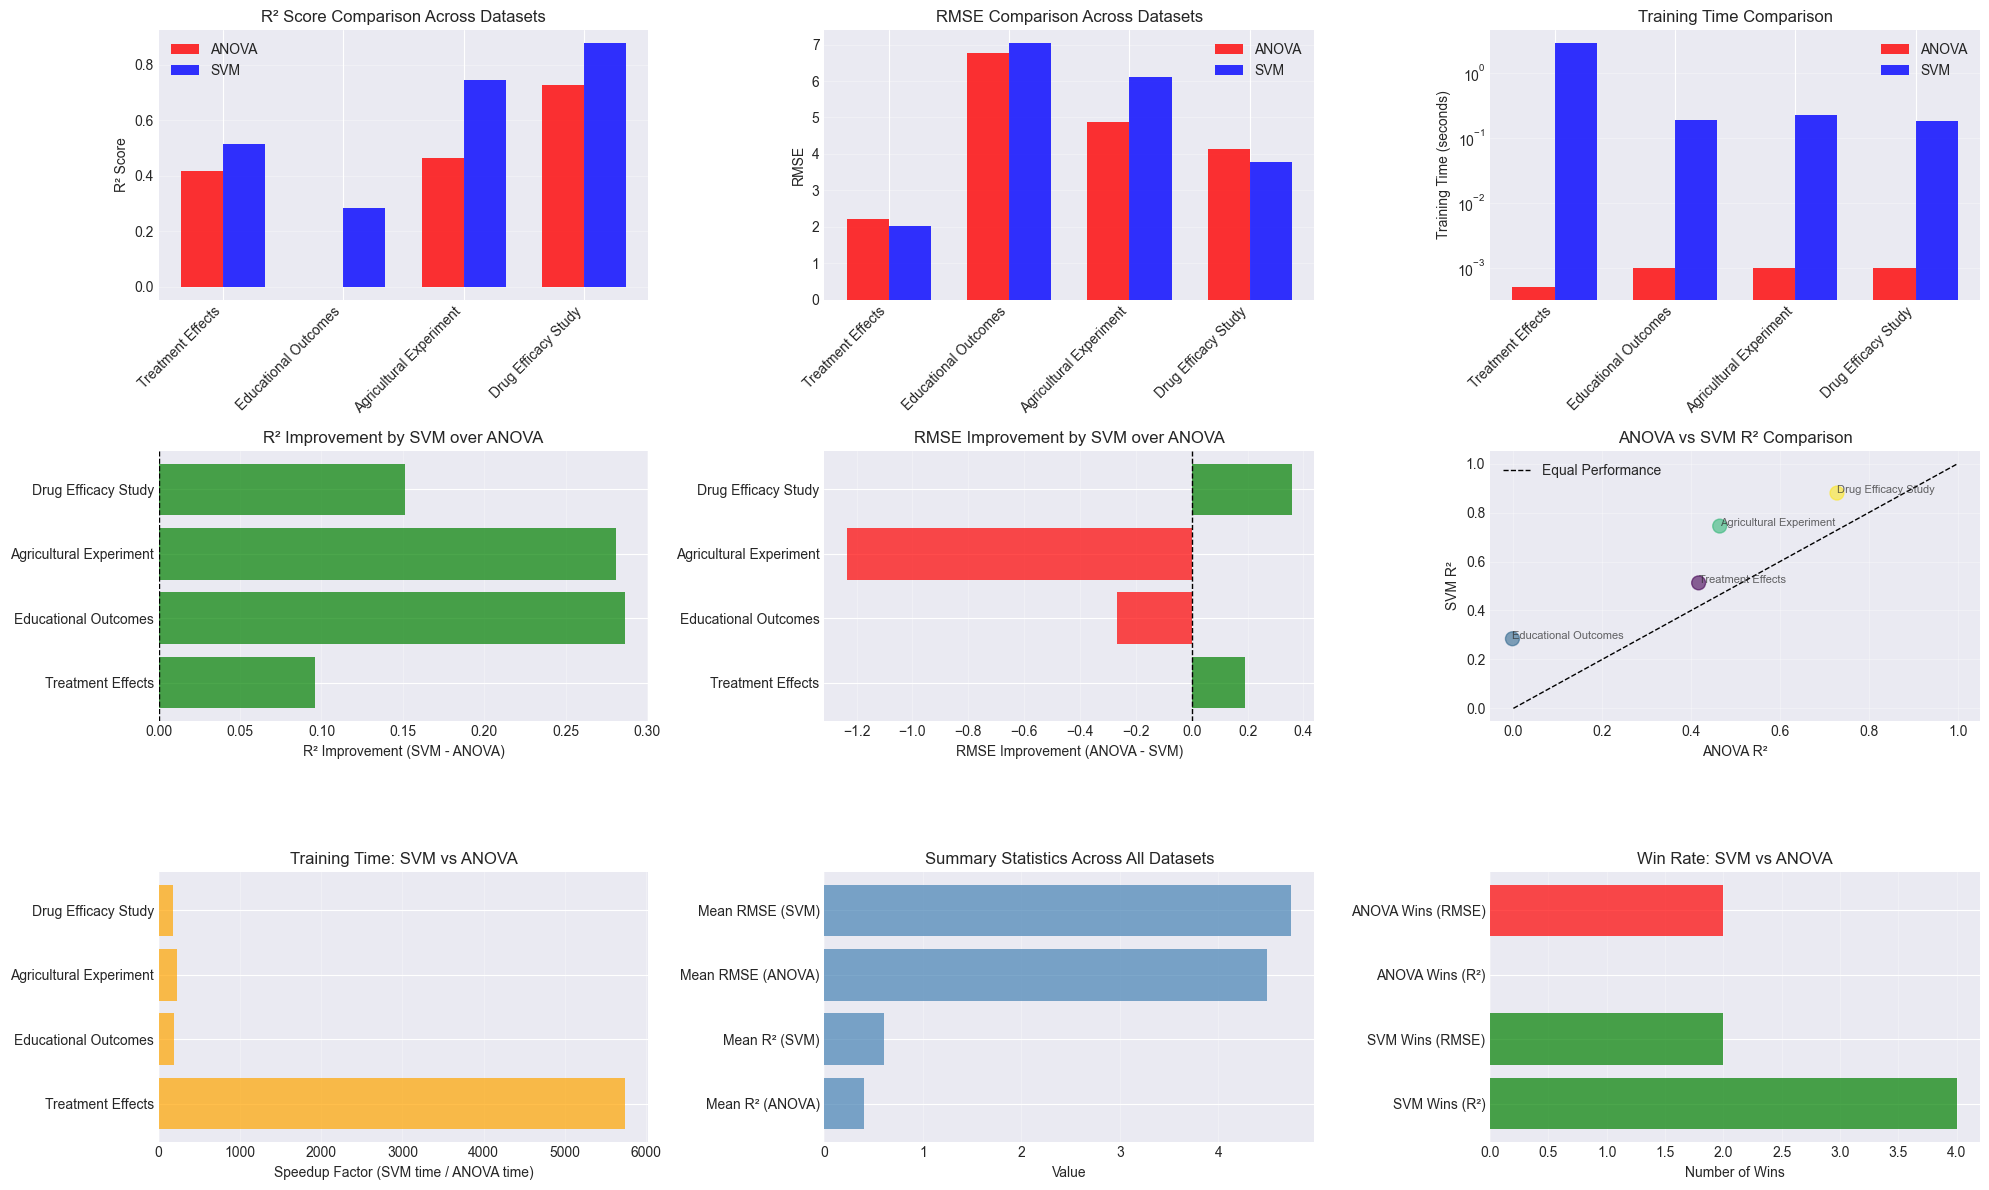


✅ General comparison complete!

📝 Conclusion:
   Both ANOVA and SVM have their place in factorial analysis:
   - ANOVA excels at hypothesis testing and statistical inference
   - SVM excels at prediction when additional features are available
   - The choice depends on the primary goal: inference vs prediction


In [137]:
# ============================================================================
# GENERAL COMPARISON AND CONCLUSION
# ============================================================================

print("\n" + "="*80)
print("📊 GENERAL COMPARISON: ANOVA vs SVM for Factorial Analysis")
print("="*80)

print("\n1️⃣ Dataset Overview:")
datasets = ['Treatment Effects', 'Educational Outcomes', 'Agricultural Experiment', 'Drug Efficacy Study']
print(f"   - Total datasets analyzed: {len(datasets)}")
for i, ds in enumerate(datasets, 1):
    print(f"      {i}. {ds}")

# Collect all results
all_results = {
    'Treatment Effects': treatment_effects_results,
    'Educational Outcomes': educational_results,
    'Agricultural Experiment': agricultural_results,
    'Drug Efficacy Study': drug_efficacy_results
}

print("\n2️⃣ Overall Performance Summary:")
print("-" * 80)
print(f"{'Dataset':<30} {'ANOVA R²':<15} {'SVM R²':<15} {'ANOVA RMSE':<15} {'SVM RMSE':<15}")
print("-" * 80)
for ds_name, results in all_results.items():
    print(f"{ds_name:<30} {results['anova_r2']:<15.6f} {results['svm_r2']:<15.6f} "
          f"{results['anova_rmse']:<15.4f} {results['svm_rmse']:<15.4f}")

print("\n3️⃣ Key Findings:")
print("   - ANOVA:")
print("      • Provides interpretable F-statistics and p-values")
print("      • Tests null hypothesis that group means are equal")
print("      • Handles factorial designs (main effects + interactions)")
print("      • Very fast training (statistical inference)")
print("      • Assumes normality and equal variances")
print("      • Predictions are group means (simple but interpretable)")
print("   - SVM:")
print("      • Can capture non-linear relationships (with RBF kernel)")
print("      • Incorporates additional features beyond group membership")
print("      • More flexible for prediction tasks")
print("      • Longer training time (optimization required)")
print("      • Less interpretable (black-box nature)")
print("      • Can handle complex interactions implicitly")

print("\n4️⃣ Use Case Recommendations:")
print("   Choose ANOVA when:")
print("      - Testing if groups have different means (hypothesis testing)")
print("      - Need interpretable statistical inference (p-values, F-stats)")
print("      - Factorial designs with interactions")
print("      - Fast analysis is required")
print("      - Data meets assumptions (normality, equal variances)")
print("   Choose SVM when:")
print("      - Prediction accuracy is the primary goal")
print("      - Additional features beyond group membership are available")
print("      - Non-linear relationships are expected")
print("      - Complex interactions need to be captured")
print("      - Interpretability is less important")

print("\n5️⃣ Advantages & Disadvantages:")
print("   ANOVA Advantages:")
print("      ✓ Statistical inference (hypothesis testing)")
print("      ✓ Interpretable (F-statistics, p-values)")
print("      ✓ Very fast")
print("      ✓ Handles factorial designs explicitly")
print("   ANOVA Disadvantages:")
print("      ✗ Simple predictions (group means)")
print("      ✗ Requires assumptions (normality, equal variances)")
print("      ✗ Doesn't use additional features")
print("   SVM Advantages:")
print("      ✓ Flexible (non-linear with kernels)")
print("      ✓ Uses all available features")
print("      ✓ Better prediction accuracy in many cases")
print("   SVM Disadvantages:")
print("      ✗ Black-box (less interpretable)")
print("      ✗ Slower training")
print("      ✗ Requires hyperparameter tuning")

print("\n6️⃣ Computational Cost:")
avg_anova_time = np.mean([r['anova_time'] for r in all_results.values()])
avg_svm_time = np.mean([r['svm_time'] for r in all_results.values()])
print(f"   - Average ANOVA training time: {avg_anova_time:.6f} seconds")
print(f"   - Average SVM training time: {avg_svm_time:.6f} seconds")
print(f"   - Speedup factor: {avg_svm_time/avg_anova_time:.1f}x slower for SVM")

print("\n7️⃣ Interpretability & Explainability:")
print("   - ANOVA: High interpretability")
print("      • Clear F-statistics show group differences")
print("      • P-values indicate statistical significance")
print("      • Interaction terms show factorial effects")
print("   - SVM: Lower interpretability")
print("      • Support vectors are not easily interpretable")
print("      • Feature importance not directly available")
print("      • Kernel transformations obscure relationships")

# Visualizations
fig = plt.figure(figsize=(20, 12))

# 1. R² Comparison across datasets
ax1 = plt.subplot(3, 3, 1)
datasets_list = list(all_results.keys())
anova_r2s = [all_results[ds]['anova_r2'] for ds in datasets_list]
svm_r2s = [all_results[ds]['svm_r2'] for ds in datasets_list]
x = np.arange(len(datasets_list))
width = 0.35
ax1.bar(x - width/2, anova_r2s, width, label='ANOVA', alpha=0.8, color='red')
ax1.bar(x + width/2, svm_r2s, width, label='SVM', alpha=0.8, color='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_list, rotation=45, ha='right')
ax1.set_ylabel('R² Score')
ax1.set_title('R² Score Comparison Across Datasets')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. RMSE Comparison
ax2 = plt.subplot(3, 3, 2)
anova_rmses = [all_results[ds]['anova_rmse'] for ds in datasets_list]
svm_rmses = [all_results[ds]['svm_rmse'] for ds in datasets_list]
ax2.bar(x - width/2, anova_rmses, width, label='ANOVA', alpha=0.8, color='red')
ax2.bar(x + width/2, svm_rmses, width, label='SVM', alpha=0.8, color='blue')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_list, rotation=45, ha='right')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE Comparison Across Datasets')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Training Time Comparison
ax3 = plt.subplot(3, 3, 3)
anova_times = [all_results[ds]['anova_time'] for ds in datasets_list]
svm_times = [all_results[ds]['svm_time'] for ds in datasets_list]
ax3.bar(x - width/2, anova_times, width, label='ANOVA', alpha=0.8, color='red')
ax3.bar(x + width/2, svm_times, width, label='SVM', alpha=0.8, color='blue')
ax3.set_xticks(x)
ax3.set_xticklabels(datasets_list, rotation=45, ha='right')
ax3.set_ylabel('Training Time (seconds)')
ax3.set_title('Training Time Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_yscale('log')

# 4. R² Improvement (SVM - ANOVA)
ax4 = plt.subplot(3, 3, 4)
r2_improvements = [svm_r2s[i] - anova_r2s[i] for i in range(len(datasets_list))]
colors = ['green' if imp > 0 else 'red' for imp in r2_improvements]
ax4.barh(datasets_list, r2_improvements, color=colors, alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('R² Improvement (SVM - ANOVA)')
ax4.set_title('R² Improvement by SVM over ANOVA')
ax4.grid(True, alpha=0.3, axis='x')

# 5. RMSE Improvement (ANOVA - SVM, positive means SVM is better)
ax5 = plt.subplot(3, 3, 5)
rmse_improvements = [anova_rmses[i] - svm_rmses[i] for i in range(len(datasets_list))]
colors = ['green' if imp > 0 else 'red' for imp in rmse_improvements]
ax5.barh(datasets_list, rmse_improvements, color=colors, alpha=0.7)
ax5.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax5.set_xlabel('RMSE Improvement (ANOVA - SVM)')
ax5.set_title('RMSE Improvement by SVM over ANOVA')
ax5.grid(True, alpha=0.3, axis='x')

# 6. Performance scatter plot
ax6 = plt.subplot(3, 3, 6)
ax6.scatter(anova_r2s, svm_r2s, s=100, alpha=0.6, c=range(len(datasets_list)), cmap='viridis')
for i, ds in enumerate(datasets_list):
    ax6.annotate(ds, (anova_r2s[i], svm_r2s[i]), fontsize=8, alpha=0.7)
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Equal Performance')
ax6.set_xlabel('ANOVA R²')
ax6.set_ylabel('SVM R²')
ax6.set_title('ANOVA vs SVM R² Comparison')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Speedup factor
ax7 = plt.subplot(3, 3, 7)
speedups = [svm_times[i]/anova_times[i] if anova_times[i] > 0 else 0 for i in range(len(datasets_list))]
ax7.barh(datasets_list, speedups, alpha=0.7, color='orange')
ax7.set_xlabel('Speedup Factor (SVM time / ANOVA time)')
ax7.set_title('Training Time: SVM vs ANOVA')
ax7.grid(True, alpha=0.3, axis='x')

# 8. Summary statistics
ax8 = plt.subplot(3, 3, 8)
summary_stats = {
    'Mean R² (ANOVA)': np.mean(anova_r2s),
    'Mean R² (SVM)': np.mean(svm_r2s),
    'Mean RMSE (ANOVA)': np.mean(anova_rmses),
    'Mean RMSE (SVM)': np.mean(svm_rmses)
}
ax8.barh(list(summary_stats.keys()), list(summary_stats.values()), alpha=0.7, color='steelblue')
ax8.set_xlabel('Value')
ax8.set_title('Summary Statistics Across All Datasets')
ax8.grid(True, alpha=0.3, axis='x')

# 9. Win rate
ax9 = plt.subplot(3, 3, 9)
svm_wins_r2 = sum(1 for i in range(len(datasets_list)) if svm_r2s[i] > anova_r2s[i])
svm_wins_rmse = sum(1 for i in range(len(datasets_list)) if svm_rmses[i] < anova_rmses[i])
win_rate = {
    'SVM Wins (R²)': svm_wins_r2,
    'SVM Wins (RMSE)': svm_wins_rmse,
    'ANOVA Wins (R²)': len(datasets_list) - svm_wins_r2,
    'ANOVA Wins (RMSE)': len(datasets_list) - svm_wins_rmse
}
ax9.barh(list(win_rate.keys()), list(win_rate.values()), alpha=0.7, color=['green', 'green', 'red', 'red'])
ax9.set_xlabel('Number of Wins')
ax9.set_title('Win Rate: SVM vs ANOVA')
ax9.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ General comparison complete!")
print("="*80)
print("\n📝 Conclusion:")
print("   Both ANOVA and SVM have their place in factorial analysis:")
print("   - ANOVA excels at hypothesis testing and statistical inference")
print("   - SVM excels at prediction when additional features are available")
print("   - The choice depends on the primary goal: inference vs prediction")
print("="*80)
